This code converts mask images into distance matrices, with labels indicating control or mutant \
For the current code, all distance matrices in a EM are either training or testing set, not intermingled. \
For mixed training and testing set, see commented code.

In [1]:
import re
import numpy as np
from PIL import Image
from pathlib import Path
import skimage
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random

#helpers = "OneDrive - University of Cambridge/ShapeEmbedLite/ConvertBinaryMasksToDMs/helpers.py"
from helpers import *

ds_path = Path.cwd()
random.seed(114514)

In [2]:
def prepare_sample():  #fname: train or test fname: str
    #path of controls and mutants
    p_control = ds_path.parent / 'raw_dataset' / 'gap43-mCherry' / fname / 'control-gap43mCherry,OskGal4,TM6'
    p_mutant = ds_path.parent / 'raw_dataset' / 'gap43-mCherry' / fname / 'mutant-sdkMB5054,gap43mCherry,CyoGla'

    samples = []
    
    #search all subroutines for png files, save the path and label
    #control labelled as 0
    for f in p_control.rglob('*.png'):
        samples.append((f, 0))
    #end for
                       
    #mutant labelled as 1
    for f in p_mutant.rglob('*.png'):
        samples.append((f, 1))
    #end for

   
    '''
    #----mixed----
    p = ds_path.parent / 'raw_dataset' / 'gap43-mCherry' 
    samples = []
    for f in p.rglob('*.png'): 
        if 'control' in str(f):
            lbl = 0
        elif 'mutant' in str(f):
            lbl = 1
        #end if
        samples.append((f, lbl))
    #end for
    '''
    
    return samples
#end def         

In [ ]:
# whole EM
samples_train = prepare_sample('train')
samples_test = prepare_sample('test')

In [3]:
# mixed
# samples = prepare_sample()

In [4]:
#convert a binary mask to a suite of points on its contour
def imageToContour(fname, n_samples = 64, resample_sparsity = 1):
    # open the image for further processing
    with Image.open(fname) as img: 
        # convert the image to a numpy array
        arr = np.array(img) 

        # extract the (longest if several) object contour
        cont = find_longest_contour(arr) 
        
        # uniformly resample the contour to a desired number of samples along a fitted spline
        return contour_spline_resample(cont, 
                                       n_samples = n_samples, 
                                       sparsity = resample_sparsity )

In [6]:
samples_contour_train = [ (imageToContour(f), lbl) for f, lbl in samples_train ]
samples_contour_test = [ (imageToContour(f), lbl) for f, lbl in samples_test ]

In [5]:
# mixed
# samples_contour = [ (imageToContour(f), lbl) for f, lbl in samples ]

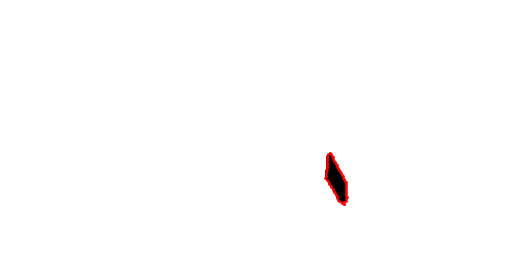

In [7]:
# demonstration of a binary mask and the sampled points
'''
idx_smpl = 2
f_smpl, lbl_smpl = samples_test[idx_smpl]
img_smpl = Image.open(f_smpl)

cont_smpl, _ = samples_contour_test[idx_smpl]

plt.imshow(img_smpl, cmap = 'gray')
plt.axis('off')
plt.scatter(cont_smpl[:, 1], cont_smpl[:, 0], s = 1, facecolor = 'red')
#plt.scatter(50,100)
plt.savefig('contours.png', bbox_inches='tight')
plt.show()
'''

In [ ]:
samples_dm_train = [ (distance_matrix(c, c), lbl) for c, lbl in samples_contour_train ]
samples_dm_test = [ (distance_matrix(c, c), lbl) for c, lbl in samples_contour_test ]

In [6]:
#mixed
# samples_dm = [ (distance_matrix(c, c), lbl) for c, lbl in samples_contour ]

C:\Users\ethan\AppData\Local\Temp\ipykernel_17524\4262503585.py:2: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  samples_dm = [ (distance_matrix(c, c), lbl) for c, lbl in samples_contour ]
C:\Users\ethan\AppData\Local\Temp\ipykernel_17524\4262503585.py:2: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  samples_dm = [ (distance_matrix(c, c), lbl) for c, lbl in samples_contour ]
C:\Users\ethan\AppData\Local\Temp\ipykernel_17524\4262503585.py:2: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  samples_dm = [ (distance_matrix(c, c), lbl) for c, lbl in samples_contour ]


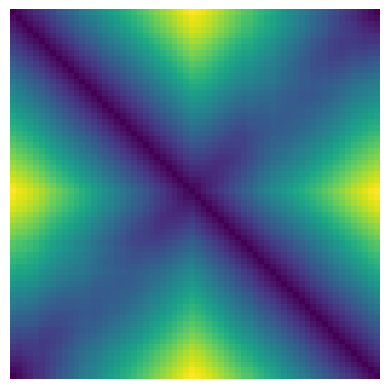

In [9]:
# demonstration of a distance matrix
'''
dm_smpl, _ = samples_dm_test[idx_smpl]

plt.imshow(dm_smpl)
plt.axis('off')
plt.savefig('contours.png', bbox_inches='tight')
plt.show()
'''

In [ ]:
random.shuffle(samples_dm_train)
random.shuffle(samples_dm_test)

In [7]:
# mixed
'''
# isolate the distance matrices `X` and the labels `y`
X = [dm for dm, _ in samples_dm]
y = [lbl for _, lbl in samples_dm]

# stratified split, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, #standard 80:20
                                                    stratify = y,
                                                    random_state = 42
                                                    )

# recombine distance matrices and labels
samples_dm_train = list(zip(X_train, y_train))
samples_dm_test = list(zip(X_test, y_test))
'''

In [8]:
# given a path on disk and a list of (distance matrix, label) pairs, dump the dataset to disk
def save_distance_matrices(root_path, dms):
    # create the folder hierarchy
    root_path.mkdir(exist_ok = True, parents = True)
    (root_path / 'control').mkdir(exist_ok = True, parents = True)
    (root_path / 'mutant').mkdir(exist_ok = True, parents = True)
    
    # dump each sample to disk in the appropriate folder
    for idx, (dm, lbl) in enumerate(dms):
        lbl_folder = 'control' if lbl == 0 else 'mutant'
        np.save(root_path / lbl_folder / f'sample_{idx}.npy', dm)
    #end for
#end deff

In [9]:
ds_train_path = ds_path.parent / "dm_dataset" / "train"
ds_test_path = ds_path.parent / "dm_dataset" / "test"

save_distance_matrices(ds_train_path, samples_dm_train)
save_distance_matrices(ds_test_path, samples_dm_test)